# Can Pokemon Stats Tell Us What Makes a Pokemon Legendary?

**CMSC 320 Final Project - Spring 2026**  
**Group repository:** https://github.com/dhruvpat27/320_final_project  
**Dataset source:** [Complete Pokemon Dataset on Kaggle](https://www.kaggle.com/datasets/rounakbanik/pokemon)

## Contributions

| Member | Sections | Contributions |
| --- | --- | --- |
| Pranjal Kattel | B, C, G | Did data pre-processing, chi-square, Welch t-test, Pearson correlation, set up final report notebook structure. |
| TODO: Name 2 | xxxx | xxxx |
| TODO: Name 3 | xxxx | xxxx |
| TODO: Name 4 | xxxx | xxxx |
| TODO: Name 5 | xxxx | xxxx |

**Contribution key:**  
A: Project idea  
B: Dataset curation and preprocessing  
C: Data exploration and summary statistics  
D: ML algorithm design/development  
E: ML algorithm training and test data analysis  
F: Visualization, result analysis, conclusion  
G: Final tutorial report creation  
H: Additional work not listed above

In [1]:
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

## Introduction

Pokemon is a good dataset for a data science tutorial because it is familiar.  Each Pokemon has typing, base stats, capture rate, generation, size, ability text, and a legendary label. That gives us enough structure to ask questions that use the full data science pipeline instead of stopping at simple counting.

The main question for this project is:

**Can we use a Pokemon's measurable traits to understand what tends to separate legendary Pokemon from the rest?**

We will build up to that question in stages. First, we clean the dataset into a form pandas can work with. Then we explore type balance, stat differences, and physical size relationships. Finally, we train a first-pass classification model that predicts whether a Pokemon is legendary from its stats, types, and other measurable attributes.

We want to see which patterns are strong enough that a model can pick them up, and whether those patterns match what players would probably expect from the franchise.

### Questions we will answer

1. Are primary Pokemon types evenly represented, or are some types much more common?
2. Do legendary Pokemon have meaningfully higher base stats than non-legendary Pokemon?
3. How strongly are height and weight connected in this dataset?
4. Can a machine learning model predict legendary status from ordinary Pokemon attributes?
5. Which features seem most useful for that prediction?

## Data Curation

The dataset has one row per Pokemon through Generation 7 and includes stats, defensive type multipliers, physical measurements, generation, and whether the Pokemon is legendary. We use the local `pokemon.csv` file that came from the Kaggle dataset linked above.

A few columns need cleaning before analysis:

- `capture_rate` is stored as text in the CSV, so we extract the numeric part and convert it to a number.
- `abilities` is stored as a string that looks like a Python list, so we parse it into an actual list.
- `height_m`, `weight_kg`, and `percentage_male` have missing values for some Pokemon. We do not drop those rows globally because the missingness is limited and different analyses need different columns.
- `type2` is blank for single-type Pokemon. For modeling, we replace it with the label `none` so the model can treat "does not have a second type" as information.

In [2]:
pokemon_raw = pd.read_csv("pokemon.csv")

pokemon = pokemon_raw.copy()
pokemon["capture_rate_clean"] = pd.to_numeric(
    pokemon["capture_rate"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)
pokemon["abilities_list"] = pokemon["abilities"].apply(ast.literal_eval)
pokemon["ability_count"] = pokemon["abilities_list"].apply(len)
pokemon["type2_filled"] = pokemon["type2"].fillna("none")
pokemon["legendary_label"] = np.where(pokemon["is_legendary"].eq(1), "Legendary", "Not legendary")

print(f"Rows: {pokemon.shape[0]:,}")
print(f"Columns before cleaning: {pokemon_raw.shape[1]:,}")
print(f"Columns after cleaning: {pokemon.shape[1]:,}")

display(pokemon[["pokedex_number", "name", "type1", "type2_filled", "base_total", "capture_rate_clean", "is_legendary"]].head())

Rows: 801
Columns before cleaning: 41
Columns after cleaning: 46


,pokedex_number,name,type1,type2_filled,base_total,capture_rate_clean,is_legendary
0,1,Bulbasaur,grass,poison,318,45,0
1,2,Ivysaur,grass,poison,405,45,0
2,3,Venusaur,grass,poison,625,45,0
3,4,Charmander,fire,none,309,45,0
4,5,Charmeleon,fire,none,405,45,0


In [3]:
missing_summary = (
    pokemon.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
    .query("missing_values > 0")
    .sort_values("missing_values", ascending=False)
)

print("Columns with missing values:")
display(missing_summary)

Columns with missing values:


,missing_values
type2,384
percentage_male,98
height_m,20
weight_kg,20


The largest missing group is `type2`, which mostly means the Pokemon only has one type. The missing height and weight values are small enough that we can drop them only for plots that need physical measurements. That keeps the rest of the dataset available for type and stat analysis.

In [4]:
numeric_columns = [
    "hp", "attack", "defense", "sp_attack", "sp_defense", "speed",
    "base_total", "height_m", "weight_kg", "capture_rate_clean",
]

numeric_summary = pokemon[numeric_columns].describe().T
print("Summary statistics for core numeric columns:")
display(numeric_summary)

Summary statistics for core numeric columns:


,count,mean,std,min,25%,50%,75%,max
hp,801.0,68.958801,26.576015,1.0,50.0,65.0,80.0,255.0
attack,801.0,77.857678,32.158820,5.0,55.0,75.0,100.0,185.0
defense,801.0,73.008739,30.769159,5.0,50.0,70.0,90.0,230.0
sp_attack,801.0,71.305868,32.353826,10.0,45.0,65.0,91.0,194.0
sp_defense,801.0,70.911361,27.942501,20.0,50.0,66.0,90.0,230.0
speed,801.0,66.334582,28.907662,5.0,45.0,65.0,85.0,180.0
base_total,801.0,428.377029,119.203577,180.0,320.0,435.0,505.0,780.0
height_m,781.0,1.163892,1.080326,0.1,0.6,1.0,1.5,14.5
weight_kg,781.0,61.378105,109.354766,0.1,9.0,27.3,64.8,999.9
capture_rate_clean,801.0,98.675406,76.248866,3.0,45.0,60.0,170.0,255.0


## Exploratory Data Analysis

This section uses three different statistical methods: a chi-square goodness-of-fit test, a Welch two-sample t test, and a Pearson correlation test. Each one checks a different kind of question, which is useful because the dataset has both categorical and numeric features.

### Conclusion 1: Primary types are not evenly represented

First, we check whether Pokemon primary types are evenly spread across the dataset. If every primary type appeared equally often, each type would have about the same count. A chi-square goodness-of-fit test lets us compare the observed type counts against that evenly-distributed baseline.

Chi-square statistic: 343.20
p-value: 1.275e-62


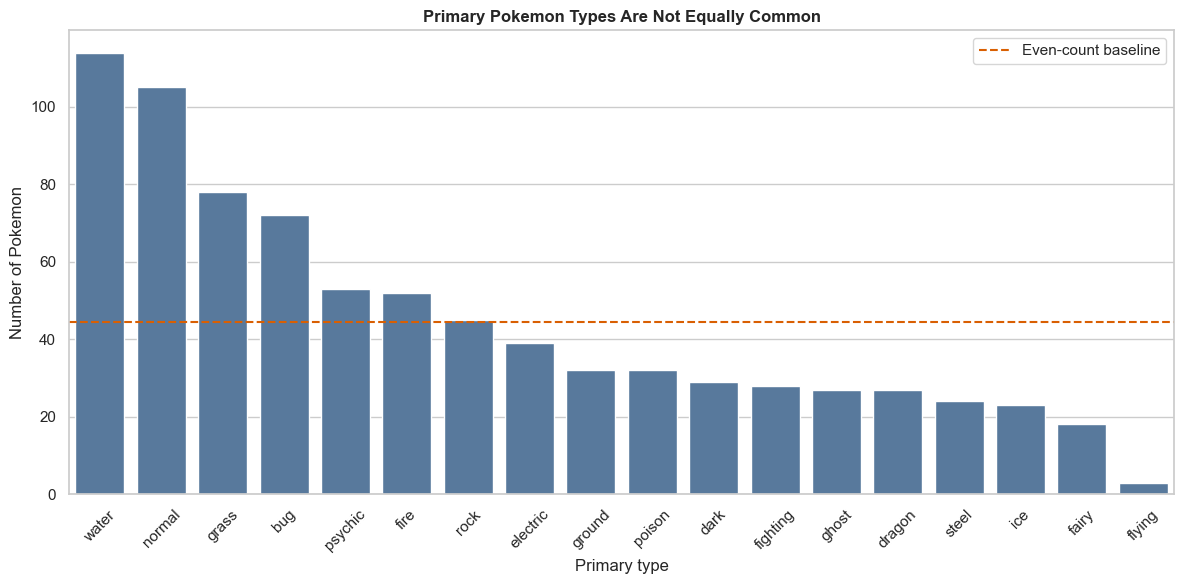

In [5]:
type_counts = pokemon["type1"].value_counts().sort_values(ascending=False)
expected_count = len(pokemon) / type_counts.shape[0]

chi_square_stat, chi_square_p = stats.chisquare(
    f_obs=type_counts.values,
    f_exp=np.repeat(expected_count, type_counts.shape[0]),
)

print(f"Chi-square statistic: {chi_square_stat:.2f}")
print(f"p-value: {chi_square_p:.4g}")

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax, color="#4C78A8")
ax.axhline(expected_count, color="#D95F02", linestyle="--", label="Even-count baseline")
ax.set_title("Primary Pokemon Types Are Not Equally Common")
ax.set_xlabel("Primary type")
ax.set_ylabel("Number of Pokemon")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** The p-value is tiny, so the primary types are not close to evenly distributed. Water has the most Pokemon, while Flying is rare as a primary type because many Flying Pokemon have it as their second type instead. This matters for later modeling because a model trained on this data sees some types much more often than others.

### Conclusion 2: Legendary Pokemon have much higher total stats

Next we compare `base_total`, which is the sum of the six main battle stats. Since legendary and non-legendary Pokemon have very different sample sizes, we use Welch's t test instead of assuming the two groups have equal variance.

Legendary mean base total: 615.3
Non-legendary mean base total: 410.5
Welch t statistic: 19.27
p-value: 4.18e-34


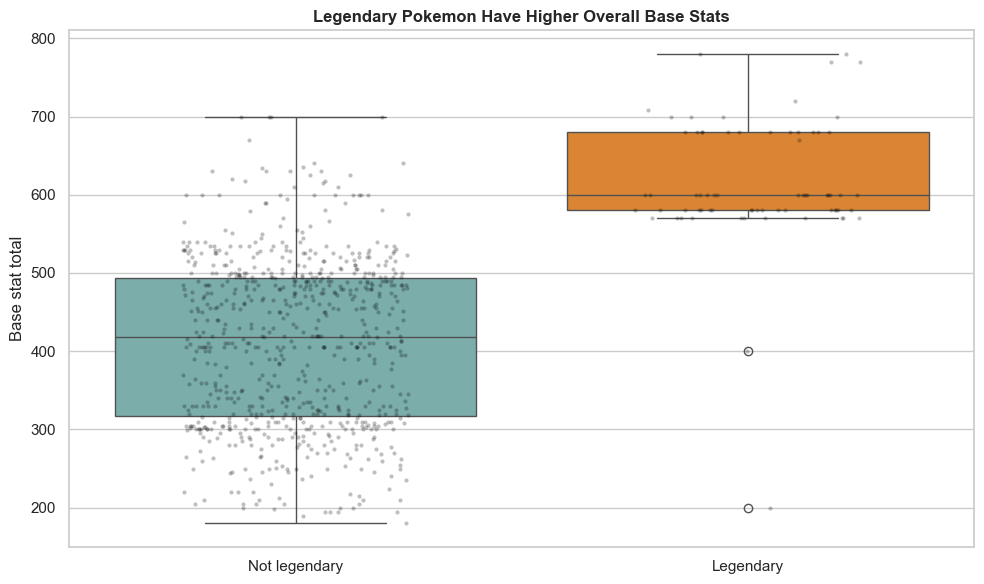

In [6]:
legendary_stats = pokemon.loc[pokemon["is_legendary"] == 1, "base_total"]
nonlegendary_stats = pokemon.loc[pokemon["is_legendary"] == 0, "base_total"]

t_stat, t_p = stats.ttest_ind(legendary_stats, nonlegendary_stats, equal_var=False)

print(f"Legendary mean base total: {legendary_stats.mean():.1f}")
print(f"Non-legendary mean base total: {nonlegendary_stats.mean():.1f}")
print(f"Welch t statistic: {t_stat:.2f}")
print(f"p-value: {t_p:.4g}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=pokemon, x="legendary_label", y="base_total", ax=ax, palette=["#72B7B2", "#F58518"])
sns.stripplot(
    data=pokemon,
    x="legendary_label",
    y="base_total",
    ax=ax,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25,
)
ax.set_title("Legendary Pokemon Have Higher Overall Base Stats")
ax.set_xlabel("")
ax.set_ylabel("Base stat total")
plt.tight_layout()
plt.show()

**Interpretation.** This result lines up with how legendary Pokemon are presented in the games. Their median and upper-range base totals sit way above the regular Pokemon distribution. There are still some strong non-legendary Pokemon, but as a group, legendary Pokemon are clearly built to be stronger.

### Conclusion 3: Height and weight are positively related, but not perfectly

For the third EDA question, we look at physical size. Pearson correlation is a good first check because both height and weight are numeric, and we want to know whether larger height usually comes with larger weight.

Pearson r: 0.627
p-value: 2.143e-86


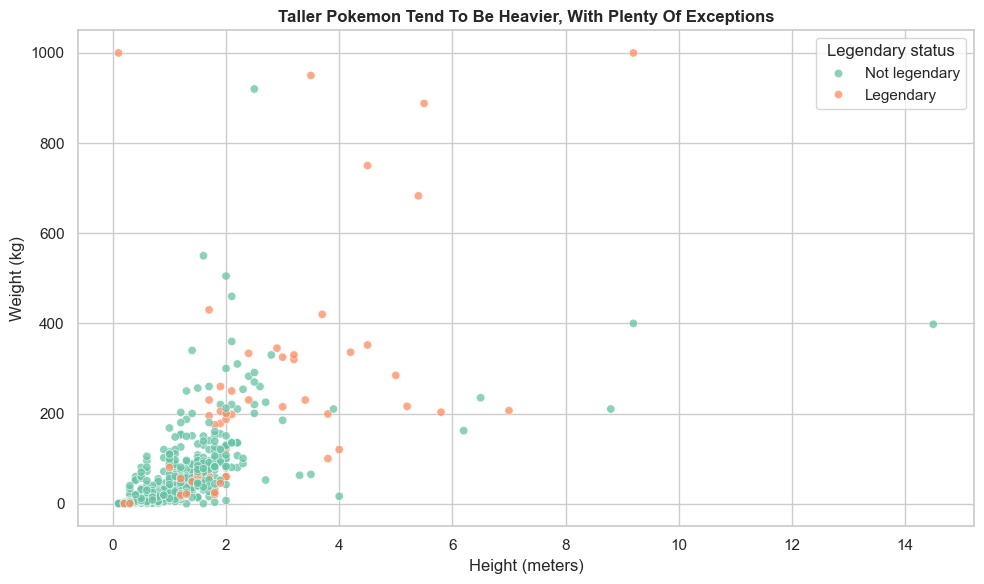

In [7]:
size_data = pokemon[["name", "height_m", "weight_kg", "legendary_label"]].dropna().copy()
r_value, r_p = stats.pearsonr(size_data["height_m"], size_data["weight_kg"])

print(f"Pearson r: {r_value:.3f}")
print(f"p-value: {r_p:.4g}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=size_data,
    x="height_m",
    y="weight_kg",
    hue="legendary_label",
    alpha=0.75,
    ax=ax,
)
ax.set_title("Taller Pokemon Tend To Be Heavier, With Plenty Of Exceptions")
ax.set_xlabel("Height (meters)")
ax.set_ylabel("Weight (kg)")
ax.legend(title="Legendary status")
plt.tight_layout()
plt.show()

**Interpretation.** Height and weight move together, but they don't tell the same thing. The relationship is positive and statistically significant, but the scatterplot still has plenty of spread. That makes sense for Pokemon because body shape matters a lot: a tall snake-like Pokemon and a tall heavy-bodied Pokemon can have very different weights.

## Primary Analysis

For the main analysis, we train a classification model to predict whether a Pokemon is legendary. This directly connects back to the project question: if a model can predict legendary status reasonably well, the model's strongest features can help us describe what separates legendary Pokemon from the rest of the dataset.

This first pass uses logistic regression because it is easier to explain than a black-box model. The model is not just trying to win a leaderboard; it should also help a reader understand the pattern. We use class weighting because only 70 of the 801 Pokemon are legendary, so the data is heavily imbalanced.

**Important choice:** We leave out `base_total` because it is just the sum of the six individual battle stats. Including it would make the model easier to read in one sense, but it would also hide which specific stats matter most.

> **TODO for teammate:** Add one comparison model, such as Random Forest or Gradient Boosting, and compare it with this logistic regression baseline using balanced accuracy, recall for legendary Pokemon, and a confusion matrix.

In [8]:
model_features = [
    "hp", "attack", "defense", "sp_attack", "sp_defense", "speed",
    "height_m", "weight_kg", "capture_rate_clean", "base_egg_steps",
    "base_happiness", "experience_growth", "generation", "ability_count",
    "type1", "type2_filled",
]

target = "is_legendary"
X = pokemon[model_features].copy()
y = pokemon[target].copy()

numeric_features = [
    "hp", "attack", "defense", "sp_attack", "sp_defense", "speed",
    "height_m", "weight_kg", "capture_rate_clean", "base_egg_steps",
    "base_happiness", "experience_growth", "generation", "ability_count",
]
categorical_features = ["type1", "type2_filled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

legendary_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2_000, class_weight="balanced", random_state=42)),
])

legendary_model.fit(X_train, y_train)
y_pred = legendary_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not legendary", "Legendary"]))

Accuracy: 0.990
Balanced accuracy: 0.995

Classification report:
               precision    recall  f1-score   support

Not legendary       1.00      0.99      0.99       183
    Legendary       0.90      1.00      0.95        18

     accuracy                           0.99       201
    macro avg       0.95      0.99      0.97       201
 weighted avg       0.99      0.99      0.99       201



Accuracy alone can look better than the model really is because most Pokemon are not legendary. Balanced accuracy is more useful here because it gives both classes equal weight. The classification report also shows whether the model is actually finding legendary Pokemon or just predicting the majority class.

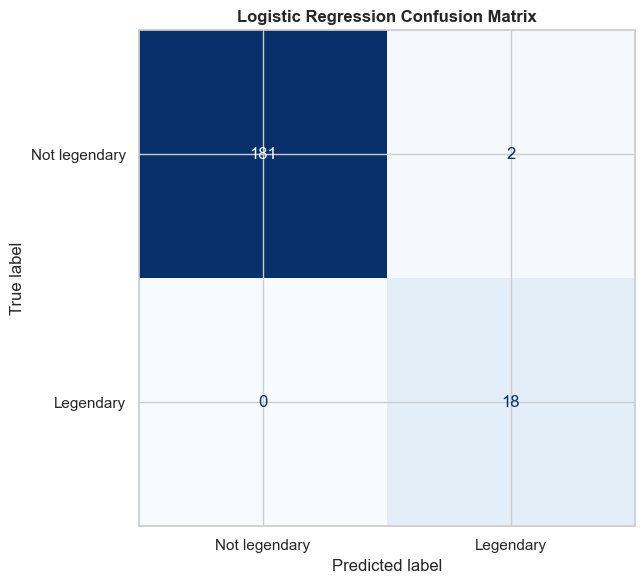

In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not legendary", "Legendary"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## Visualization and Model Interpretation

A confusion matrix tells us how often the model gets each class right, but it does not explain what the model is using. Since logistic regression has coefficients, we can inspect the largest positive coefficients as the features most associated with the model predicting "legendary." Negative coefficients push the model toward "not legendary."

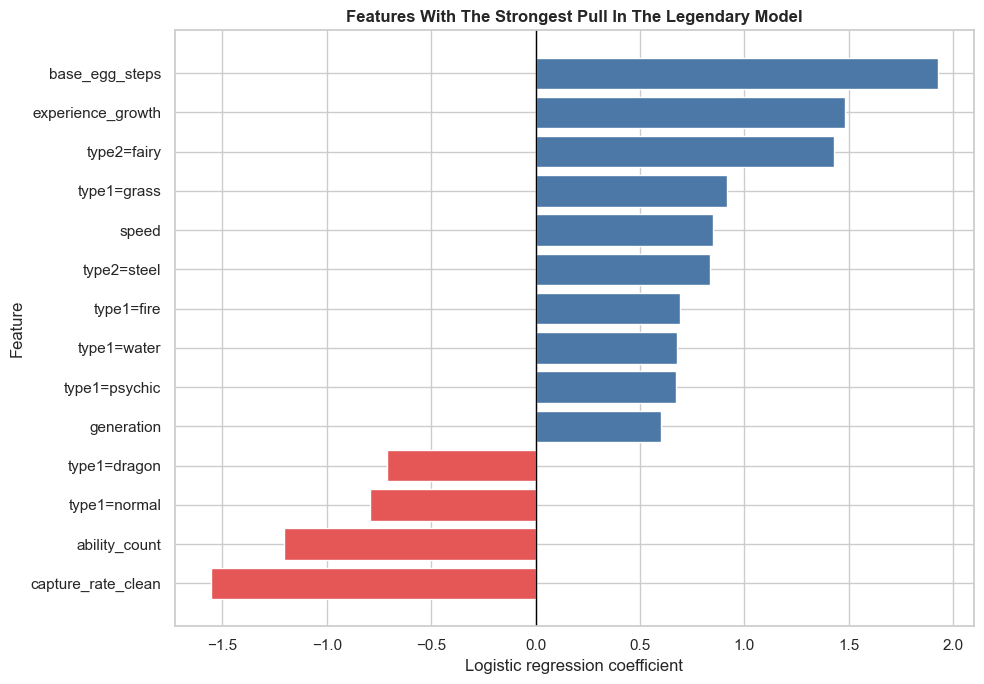

,feature_clean,coefficient
9,base_egg_steps,1.926329
8,capture_rate_clean,-1.555194
11,experience_growth,1.481241
36,type2=fairy,1.430107
13,ability_count,-1.202451
23,type1=grass,0.915256
5,speed,0.851621
49,type2=steel,0.838193
26,type1=normal,-0.793688
16,type1=dragon,-0.709693


In [10]:
feature_names = legendary_model.named_steps["preprocess"].get_feature_names_out()
coefficients = legendary_model.named_steps["model"].coef_[0]

coef_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda df: df["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

# Clean up feature names so the plot is readable.
coef_table["feature_clean"] = (
    coef_table["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("type2_filled_", "type2=", regex=False)
    .str.replace("type1_", "type1=", regex=False)
)

top_coef = coef_table.head(14).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
colors = np.where(top_coef["coefficient"] > 0, "#4C78A8", "#E45756")
ax.barh(top_coef["feature_clean"], top_coef["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Features With The Strongest Pull In The Legendary Model")
ax.set_xlabel("Logistic regression coefficient")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

display(coef_table[["feature_clean", "coefficient"]].head(10))

**Interpretation.** The first-pass model mostly leans on battle strength, rarity-related fields, and some type information. That is a reasonable result: legendary Pokemon are usually designed to feel powerful and harder to obtain. The coefficient plot should not be read as perfect proof of game design, but it gives us a transparent way to explain what the model found.

> **TODO for teammate:** Add a short comparison between this coefficient plot and the EDA results. For example, if special attack or speed appears important, connect that back to what the boxplot showed about legendary stat totals.

## Insights and Conclusions

So far, the analysis supports a few clear points:

1. Pokemon types are not evenly represented. Some types, especially Water, appear much more often as primary types.
2. Legendary Pokemon have much higher total stats on average, and that difference is statistically strong.
3. Height and weight are related, but Pokemon design leaves plenty of room for unusual body shapes.
4. A simple, explainable classifier can predict legendary status better than a naive majority-class guess, especially when we account for class imbalance.

The bigger takeaway is that legendary status is not random in this dataset. It shows up through a mixture of higher battle stats, rarity-style variables, and some typing patterns. That matches player intuition, but the tutorial makes the pattern measurable.

### What the group should finish next

- **Model comparison:** Add at least one stronger model and explain whether the extra complexity is worth it.
- **Final visualization:** Create one polished result plot that combines model performance and interpretation, or add a type-by-legendary visualization.
- **Conclusion polish:** Replace this draft conclusion with a tighter final version after the team adds the remaining work.
- **Publication:** Export the notebook to HTML and publish it through GitHub Pages.

### Possible extensions

- Predict primary type from defensive multipliers or stats.
- Cluster Pokemon by stat profile and see whether legendary Pokemon form their own cluster.
- Compare generations to see whether legendary Pokemon became more common or stronger over time.
- Add confidence intervals or permutation testing for the model's performance.

## References and Helpful Links

- Dataset: [Complete Pokemon Dataset on Kaggle](https://www.kaggle.com/datasets/rounakbanik/pokemon)
- pandas documentation: https://pandas.pydata.org/docs/
- seaborn plotting guide: https://seaborn.pydata.org/tutorial.html
- scipy statistical tests: https://docs.scipy.org/doc/scipy/reference/stats.html
- scikit-learn logistic regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- GitHub Pages guide: https://pages.github.com/
- CMSC 320 publication tutorial: https://azhou4847.github.io/CMSC320ProjectPublication/